In [1]:
from scipy.stats import skew
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(42)

In [ ]:
def run_simulation(nu, w, tau, dt = 0.0001):
    times = np.arange(0, 1000, dt)
    V = np.zeros(len(times))
    decay_factor = np.exp(-dt / tau)

    for t in range(1, len(times)):
        event = np.random.poisson(nu * dt)
        V[t] = V[t-1] * decay_factor + w * event

    V_steady = V[times > 500] # Discard the first 500 seconds to ensure steady state

    mean_empirical = np.mean(V_steady)
    variance_empirical = np.var(V_steady)
    skewness_empirical = skew(V_steady)

    mean_theoretical = nu * w * tau
    variance_theoretical = (nu * w**2 * tau) / 2
    skewness_theoretical = ((nu * w**3 * tau) / 3) / (variance_theoretical ** (3/2))

    print(f"{'Statistic:':<12} {'Empirical':<12} {'Theoretical':<12}")
    print(f"{'Mean':<12} {mean_empirical:<12.4f} {mean_theoretical:<12.4f}")
    print(f"{'Variance':<12} {variance_empirical:<12.4f} {variance_theoretical:<12.4f}")
    print(f"{'Skewness':<12} {skewness_empirical:<12.4f} {skewness_theoretical:<12.4f}")

    return V_steady

In [ ]:
tau = 0.02 # 20 ms
Vs = []

for nu_tau in [2, 20, 200]:
    nu = nu_tau / tau
    w = 10 / nu_tau # Hold <V> fixed at 10 mV
    Vs.append(run_simulation(nu, w, tau, dt = 0.0001))
    print("-" * 40)

Statistic:   Empirical    Theoretical 
Mean         9.9756       10.0000     
Variance     25.0824      25.0000     
Skewness     0.6723       0.6667      
----------------------------------------
Statistic:   Empirical    Theoretical 
Mean         10.0121      10.0000     
Variance     2.4772       2.5000      
Skewness     0.2074       0.2108      
----------------------------------------
Statistic:   Empirical    Theoretical 
Mean         10.0246      10.0000     
Variance     0.2495       0.2500      
Skewness     0.0364       0.0667      
----------------------------------------


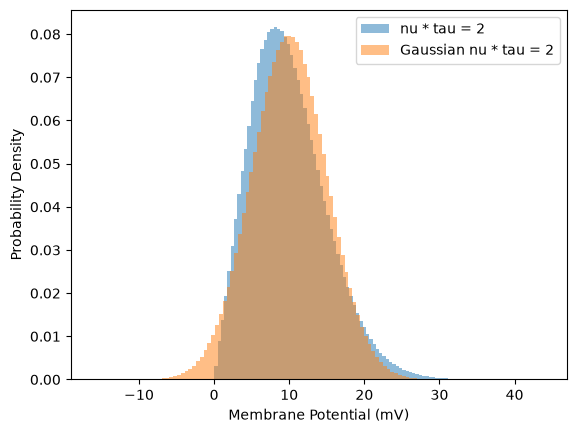

In [16]:
nu_tau = 2
nu = nu_tau / tau
w = 10 / nu_tau
gaussian_nu_tau_2 = np.random.normal(loc = 10, scale = np.sqrt((nu * w**2 * tau) / 2), size = len(Vs[0]))

plt.hist(Vs[0], bins = 100, density = True, alpha = 0.5, label = "nu * tau = 2")
plt.hist(gaussian_nu_tau_2, bins = 100, density = True, alpha = 0.5, label = "Gaussian nu * tau = 2")

plt.xlabel("Membrane Potential (mV)")
plt.ylabel("Probability Density")

plt.legend()

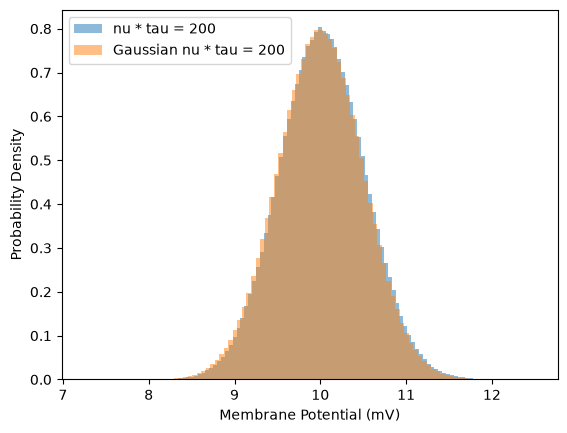

In [17]:
nu_tau = 200
nu = nu_tau / tau
w = 10 / nu_tau
gaussian_nu_tau_200 = np.random.normal(loc = 10, scale = np.sqrt((nu * w**2 * tau) / 2), size = len(Vs[2]))

plt.hist(Vs[2], bins = 100, density = True, alpha = 0.5, label = "nu * tau = 200")
plt.hist(gaussian_nu_tau_200, bins = 100, density = True, alpha = 0.5, label = "Gaussian nu * tau = 200")

plt.xlabel("Membrane Potential (mV)")
plt.ylabel("Probability Density")

plt.legend()

In [15]:
print(min(Vs[0]), max(Vs[0]))

0.018274546963863943 43.92762479584324


In [10]:
len(np.arange(0, 1000, 0.0001) / 2 - 1)

10000000